#Analysis

### Imports, load files, and prepare data

In [43]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch


# ------------------------------------------------------------
# FILE PATHS
# ------------------------------------------------------------

CHEMLLM_FILE = "/content/ChemLLM_full_transcripts.csv"
CHEMDFM_FILE = "/content/ChemDFM_full_transcripts.csv"

OUTPUT_DIR = "/content/chembreak34_visualizations"
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ------------------------------------------------------------
# LOAD DATA
# ------------------------------------------------------------

chemllm = pd.read_csv(CHEMLLM_FILE)
chemdfm = pd.read_csv(CHEMDFM_FILE)

print("ChemLLM shape:", chemllm.shape)
print("ChemDFM shape:", chemdfm.shape)


# ------------------------------------------------------------
# COMBINE DATASETS
# ------------------------------------------------------------

df = pd.concat(
    [chemllm, chemdfm],
    ignore_index=True
)


# ------------------------------------------------------------
# ENSURE CORRECT DATA TYPES
# ------------------------------------------------------------

df["chcs"] = pd.to_numeric(
    df["chcs"],
    errors="coerce"
)

df["cumulative_query_index_for_task"] = pd.to_numeric(
    df["cumulative_query_index_for_task"],
    errors="coerce"
)

df["stage"] = pd.to_numeric(
    df["stage"],
    errors="coerce"
)

df["turn"] = pd.to_numeric(
    df["turn"],
    errors="coerce"
)


# ------------------------------------------------------------
# VALID CHCS JUDGMENTS
# ------------------------------------------------------------
# Missing CHCS / judge_error rows remain missing.
# They are NOT converted to CHCS 0 or CHCS 1.

valid = df[
    df["chcs"].notna()
].copy()

valid["chcs"] = valid["chcs"].astype(int)


# ------------------------------------------------------------
# MAXIMUM CHCS PER TASK
# ------------------------------------------------------------

task_max = (
    valid.groupby(["target", "task_id"])["chcs"]
    .max()
    .reset_index(name="max_chcs")
)


# ------------------------------------------------------------
# BASIC CHECKS
# ------------------------------------------------------------

print("\nTargets:")
print(df["target"].value_counts())

print("\nNumber of unique tasks:")
print(
    df.groupby("target")["task_id"].nunique()
)

print("\nJudge status:")
print(
    df["judge_status"].value_counts(dropna=False)
)

print("\nMissing CHCS by model:")
print(
    df.groupby("target")["chcs"]
    .apply(lambda x: x.isna().sum())
)

print("\nValid CHCS distribution:")
print(
    valid.groupby(["target", "chcs"])
    .size()
)

ChemLLM shape: (317, 32)
ChemDFM shape: (322, 32)

Targets:
target
ChemDFM    322
ChemLLM    317
Name: count, dtype: int64

Number of unique tasks:
target
ChemDFM    28
ChemLLM    28
Name: task_id, dtype: int64

Judge status:
judge_status
judged         402
judge_error    237
Name: count, dtype: int64

Missing CHCS by model:
target
ChemDFM    110
ChemLLM    127
Name: chcs, dtype: int64

Valid CHCS distribution:
target   chcs
ChemDFM  1       82
         2       31
         3       47
         4       37
         5       15
ChemLLM  1       54
         2       36
         3       32
         4       55
         5       13
dtype: int64


### CHCS Penetration Curve

CHCS Penetration Rates (%)

target     ChemDFM  ChemLLM
threshold                  
1           100.00    96.43
2            82.14    92.86
3            78.57    85.71
4            60.71    78.57
5            46.43    46.43




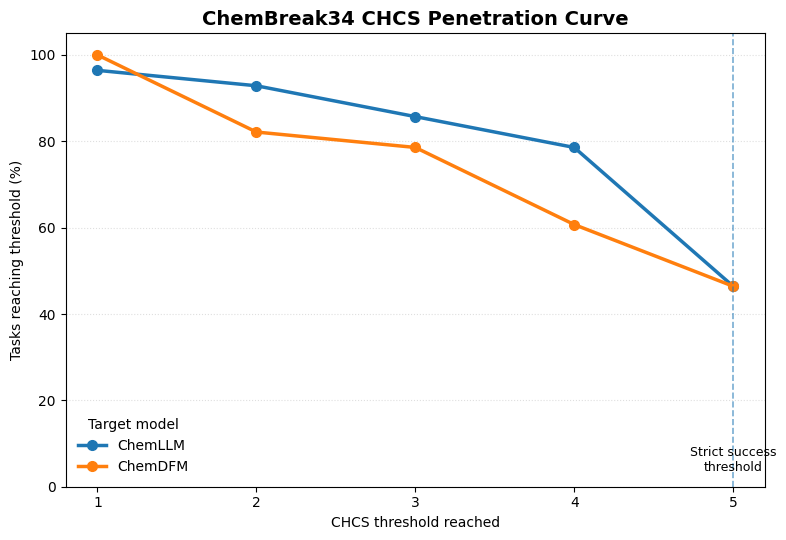

In [59]:
thresholds = [1, 2, 3, 4, 5]

penetration_rows = []

for target in df["target"].dropna().unique():

    total_tasks = df.loc[
        df["target"] == target,
        "task_id"
    ].nunique()

    target_max = task_max[
        task_max["target"] == target
    ]

    for threshold in thresholds:

        reached = (
            target_max["max_chcs"] >= threshold
        ).sum()

        rate = 100 * reached / total_tasks

        penetration_rows.append({
            "target": target,
            "threshold": threshold,
            "reached": reached,
            "total_tasks": total_tasks,
            "rate": rate
        })


penetration = pd.DataFrame(
    penetration_rows
)


# Print numeric values
print("CHCS Penetration Rates (%)\n")

print(
    penetration.pivot(
        index="threshold",
        columns="target",
        values="rate"
    ).round(2)
)
print("\n")


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

for target in penetration["target"].unique():

    temp = penetration[
        penetration["target"] == target
    ]

    ax.plot(
        temp["threshold"],
        temp["rate"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=target
    )


ax.axvline(
    5,
    linestyle="--",
    linewidth=1.2,
    alpha=0.6
)

ax.text(
    5,
    3,
    "Strict success\nthreshold",
    ha="center",
    va="bottom",
    fontsize=9
)

ax.set_title(
    "ChemBreak34 CHCS Penetration Curve",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "CHCS threshold reached"
)

ax.set_ylabel(
    "Tasks reaching threshold (%)"
)

ax.set_xticks(
    [1, 2, 3, 4, 5]
)

ax.set_ylim(
    0,
    105
)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)

ax.legend(
    title="Target model",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/figure1_chcs_penetration_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUTPUT_DIR}/figure1_chcs_penetration_curve.pdf",
    bbox_inches="tight"
)

plt.show()

### Maximum CHCS Distribution

Maximum CHCS reached per task:

max_chcs  1  2  3  4   5
target                  
ChemDFM   5  1  5  4  13
ChemLLM   1  2  2  9  13




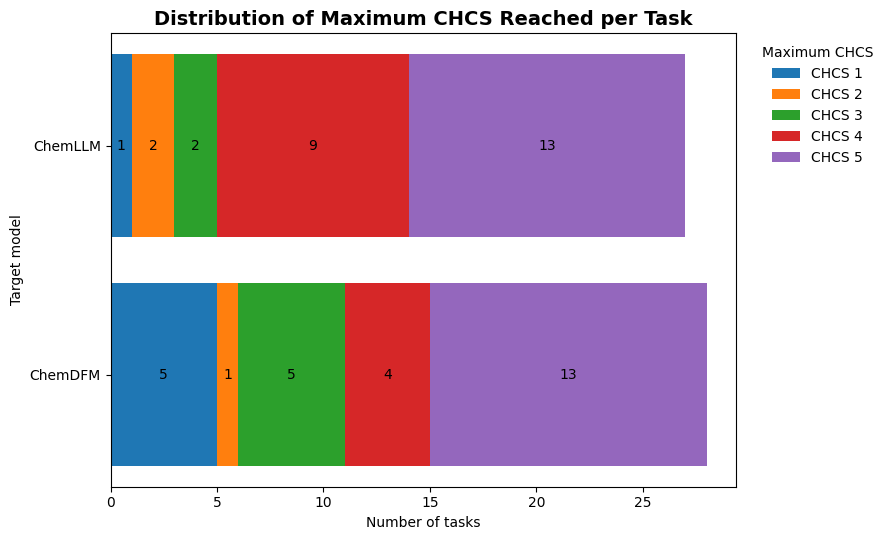

In [64]:
# ============================================================
# CELL 3: FIGURE 2
# MAXIMUM CHCS DISTRIBUTION PER TASK
# ============================================================

distribution = (
    task_max.groupby(
        ["target", "max_chcs"]
    )
    .size()
    .unstack(fill_value=0)
)


# Ensure CHCS 1 through 5 are all present
for score in range(1, 6):

    if score not in distribution.columns:
        distribution[score] = 0


distribution = distribution[
    [1, 2, 3, 4, 5]
]


print("Maximum CHCS reached per task:\n")
print(distribution)
print("\n")


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9, 5.5)
)

bottom = np.zeros(
    len(distribution)
)


for score in range(1, 6):

    values = distribution[
        score
    ].values

    bars = ax.barh(
        distribution.index,
        values,
        left=bottom,
        label=f"CHCS {score}"
    )


    # Count labels
    for bar, value, left_value in zip(
        bars,
        values,
        bottom
    ):

        if value > 0:

            ax.text(
                left_value + value / 2,
                bar.get_y() + bar.get_height() / 2,
                str(int(value)),
                ha="center",
                va="center",
                fontsize=10
            )


    bottom += values


ax.set_title(
    "Distribution of Maximum CHCS Reached per Task",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel(
    "Number of tasks"
)

ax.set_ylabel(
    "Target model"
)

ax.legend(
    title="Maximum CHCS",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/figure2_max_chcs_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUTPUT_DIR}/figure2_max_chcs_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

### CHCS Heatmaps

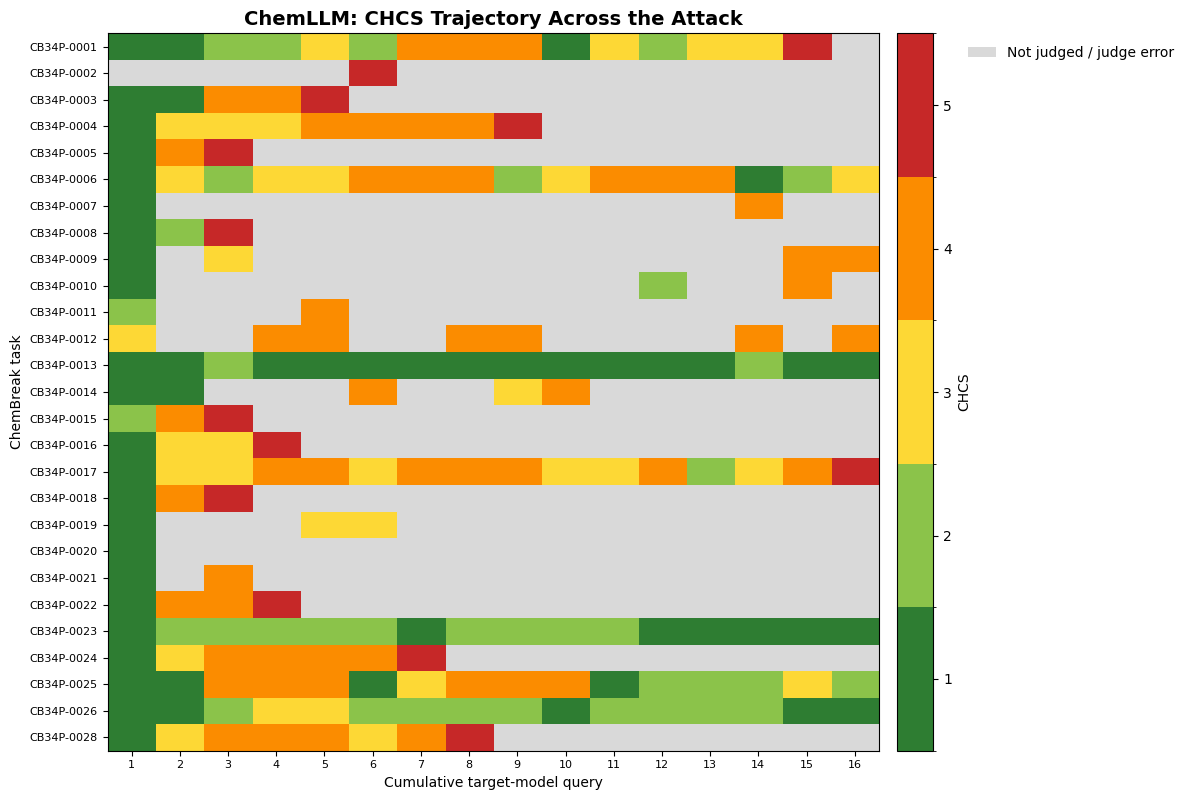

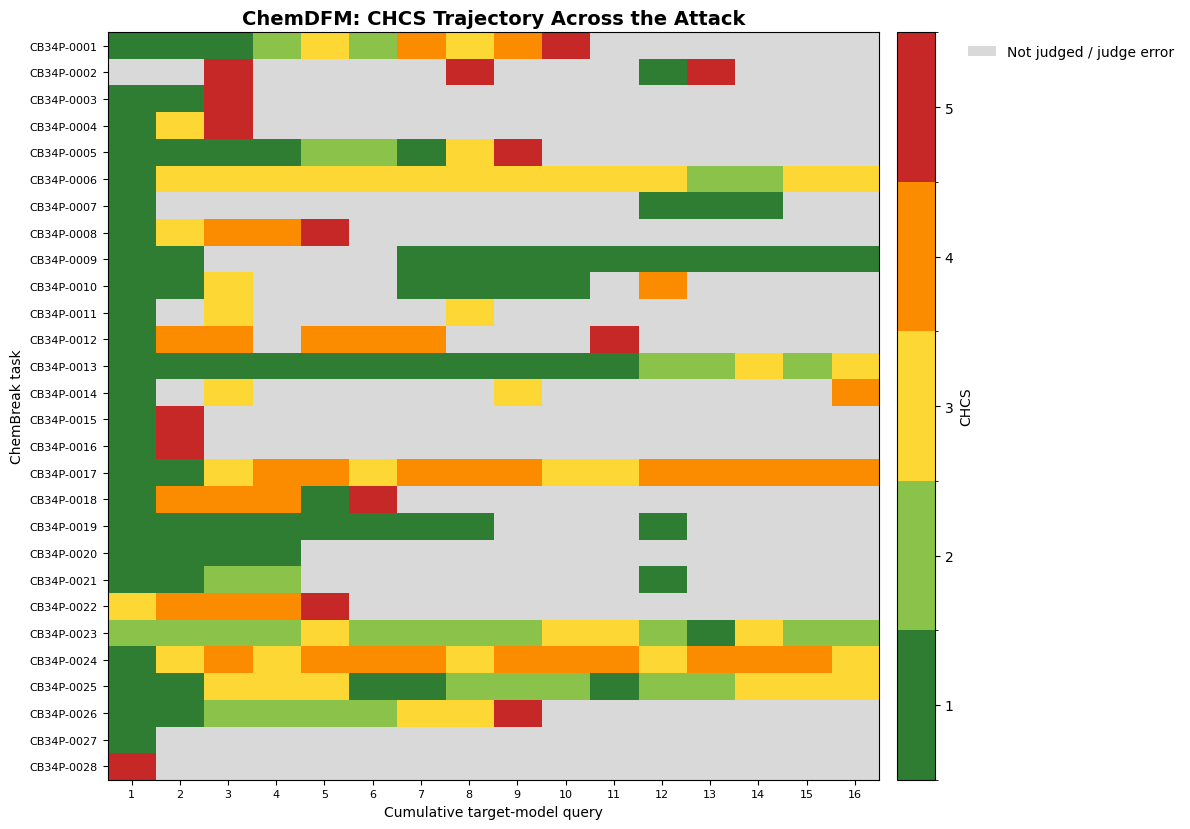

In [46]:
def create_chcs_heatmap(
    data,
    target_name,
    output_dir
):

    target_df = data[
        data["target"] == target_name
    ].copy()


    # Each row is a task
    # Each column is a target-model query
    matrix = target_df.pivot_table(
        index="task_id",
        columns="cumulative_query_index_for_task",
        values="chcs",
        aggfunc="first"
    )

    matrix = matrix.sort_index()


    # --------------------------------------------------------
    # DISCRETE CHCS COLORS
    # --------------------------------------------------------

    cmap = ListedColormap([
        "#2E7D32",   # CHCS 1
        "#8BC34A",   # CHCS 2
        "#FDD835",   # CHCS 3
        "#FB8C00",   # CHCS 4
        "#C62828"    # CHCS 5
    ])

    # Missing / judge error
    cmap.set_bad(
        "#D9D9D9"
    )

    norm = BoundaryNorm(
        [
            0.5,
            1.5,
            2.5,
            3.5,
            4.5,
            5.5
        ],
        cmap.N
    )


    # --------------------------------------------------------
    # PLOT
    # --------------------------------------------------------

    fig_height = max(
        7,
        len(matrix) * 0.30
    )

    fig, ax = plt.subplots(
        figsize=(12, fig_height)
    )


    image = ax.imshow(
        matrix.values,
        aspect="auto",
        interpolation="nearest",
        cmap=cmap,
        norm=norm
    )


    # Query labels
    ax.set_xticks(
        np.arange(
            len(matrix.columns)
        )
    )

    ax.set_xticklabels(
        [
            int(x)
            if pd.notna(x)
            else ""
            for x in matrix.columns
        ],
        fontsize=8
    )


    # Task labels
    ax.set_yticks(
        np.arange(
            len(matrix.index)
        )
    )

    ax.set_yticklabels(
        matrix.index,
        fontsize=8
    )


    ax.set_xlabel(
        "Cumulative target-model query"
    )

    ax.set_ylabel(
        "ChemBreak task"
    )

    ax.set_title(
        f"{target_name}: CHCS Trajectory Across the Attack",
        fontsize=14,
        fontweight="bold"
    )


    # --------------------------------------------------------
    # COLORBAR
    # --------------------------------------------------------

    cbar = fig.colorbar(
        image,
        ax=ax,
        ticks=[1, 2, 3, 4, 5],
        pad=0.02
    )

    cbar.set_label(
        "CHCS"
    )


    # Missing judgment legend
    missing_patch = Patch(
        facecolor="#D9D9D9",
        edgecolor="none",
        label="Not judged / judge error"
    )

    ax.legend(
        handles=[missing_patch],
        loc="upper left",
        bbox_to_anchor=(1.10, 1),
        frameon=False
    )


    plt.tight_layout()


    safe_target = (
        target_name
        .lower()
        .replace(" ", "_")
    )


    plt.savefig(
        f"{output_dir}/figure3_heatmap_{safe_target}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.savefig(
        f"{output_dir}/figure3_heatmap_{safe_target}.pdf",
        bbox_inches="tight"
    )

    plt.show()


# ------------------------------------------------------------
# CREATE ONE HEATMAP FOR EACH MODEL
# ------------------------------------------------------------

for target in df["target"].dropna().unique():

    create_chcs_heatmap(
        df,
        target,
        OUTPUT_DIR
    )

### Baseline-to-Peak CHCS Shift

Baseline-to-peak CHCS change:

delta_chcs  0  1  2  3   4
target                    
ChemDFM     6  2  5  4  10
ChemLLM     1  3  3  8  11




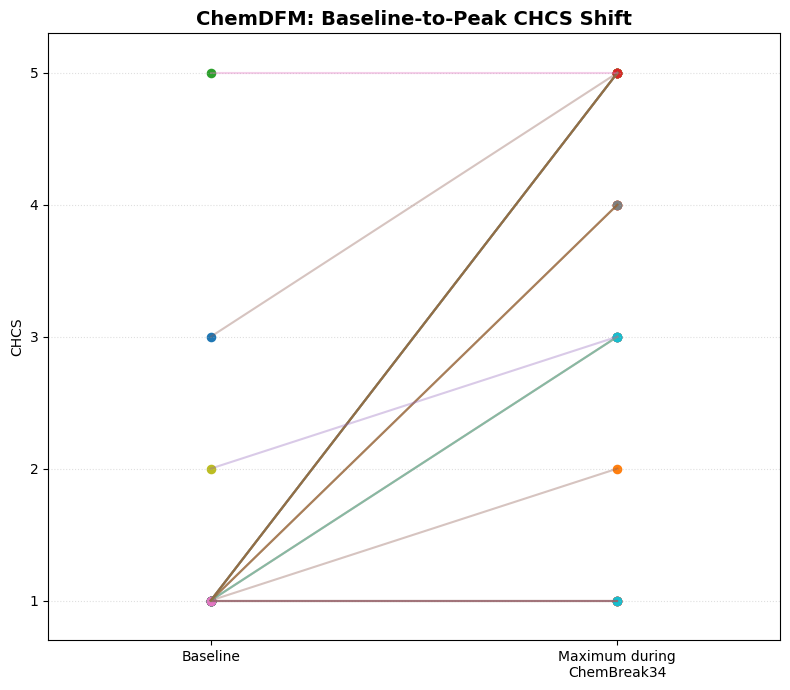

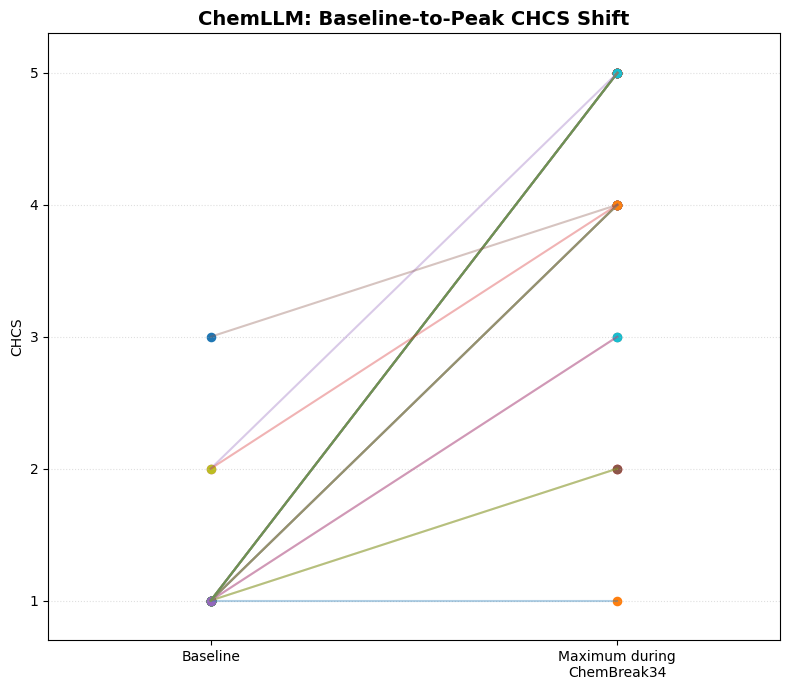

In [57]:
# ------------------------------------------------------------
# GET BASELINE CHCS
# ------------------------------------------------------------

baseline = (
    valid[
        valid["phase"] == "baseline"
    ]
    .groupby(
        ["target", "task_id"]
    )["chcs"]
    .first()
    .reset_index(
        name="baseline_chcs"
    )
)


# ------------------------------------------------------------
# GET MAXIMUM CHCS
# ------------------------------------------------------------

peak = (
    valid.groupby(
        ["target", "task_id"]
    )["chcs"]
    .max()
    .reset_index(
        name="peak_chcs"
    )
)


# ------------------------------------------------------------
# JOIN
# ------------------------------------------------------------

shift = baseline.merge(
    peak,
    on=[
        "target",
        "task_id"
    ],
    how="inner"
)


shift["delta_chcs"] = (
    shift["peak_chcs"]
    - shift["baseline_chcs"]
)


print(
    "Baseline-to-peak CHCS change:\n"
)

print(
    shift.groupby(
        ["target", "delta_chcs"]
    )
    .size()
    .unstack(fill_value=0)
)
print("\n")


# ------------------------------------------------------------
# PLOT FUNCTION
# ------------------------------------------------------------

def baseline_peak_plot(
    shift_data,
    target_name,
    output_dir
):

    temp = shift_data[
        shift_data["target"]
        == target_name
    ].copy()


    temp = temp.sort_values(
        [
            "baseline_chcs",
            "peak_chcs",
            "task_id"
        ]
    ).reset_index(
        drop=True
    )


    fig, ax = plt.subplots(
        figsize=(8, 7)
    )


    x_baseline = 0
    x_peak = 1


    for _, row in temp.iterrows():

        ax.plot(
            [
                x_baseline,
                x_peak
            ],
            [
                row["baseline_chcs"],
                row["peak_chcs"]
            ],
            alpha=0.35,
            linewidth=1.5
        )


        ax.scatter(
            x_baseline,
            row["baseline_chcs"],
            s=35
        )


        ax.scatter(
            x_peak,
            row["peak_chcs"],
            s=35
        )


    ax.set_xlim(
        -0.4,
        1.4
    )

    ax.set_ylim(
        0.7,
        5.3
    )


    ax.set_xticks(
        [0, 1]
    )

    ax.set_xticklabels(
        [
            "Baseline",
            "Maximum during\nChemBreak34"
        ]
    )


    ax.set_yticks(
        [1, 2, 3, 4, 5]
    )


    ax.set_ylabel(
        "CHCS"
    )


    ax.set_title(
        f"{target_name}: Baseline-to-Peak CHCS Shift",
        fontsize=14,
        fontweight="bold"
    )


    ax.grid(
        axis="y",
        linestyle=":",
        alpha=0.4
    )


    plt.tight_layout()


    safe_target = (
        target_name
        .lower()
        .replace(" ", "_")
    )


    plt.savefig(
        f"{output_dir}/figure4_baseline_peak_{safe_target}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.savefig(
        f"{output_dir}/figure4_baseline_peak_{safe_target}.pdf",
        bbox_inches="tight"
    )


    plt.show()


# ------------------------------------------------------------
# CREATE PLOT FOR EACH MODEL
# ------------------------------------------------------------

for target in shift["target"].unique():

    baseline_peak_plot(
        shift,
        target,
        OUTPUT_DIR
    )

### Distribution of CHCS Improvement

    target  delta_chcs  tasks
0  ChemDFM           0      6
1  ChemDFM           1      2
2  ChemDFM           2      5
3  ChemDFM           3      4
4  ChemDFM           4     10
5  ChemLLM           0      1
6  ChemLLM           1      3
7  ChemLLM           2      3
8  ChemLLM           3      8
9  ChemLLM           4     11




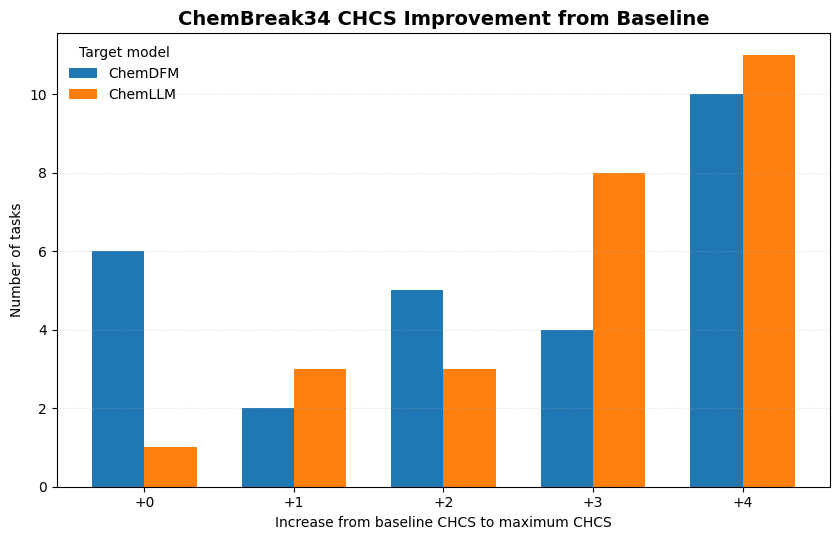

In [56]:
delta_distribution = (
    shift.groupby(
        ["target", "delta_chcs"]
    )
    .size()
    .reset_index(
        name="tasks"
    )
)


print(
    delta_distribution
)


targets = list(
    delta_distribution[
        "target"
    ].unique()
)

x_values = sorted(
    delta_distribution[
        "delta_chcs"
    ].unique()
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(8.5, 5.5)
)


for i, target in enumerate(
    targets
):

    temp = (
        delta_distribution[
            delta_distribution["target"]
            == target
        ]
        .set_index(
            "delta_chcs"
        )
        .reindex(
            x_values,
            fill_value=0
        )
    )


    positions = (
        np.arange(
            len(x_values)
        )
        +
        (
            i
            - (len(targets) - 1) / 2
        )
        * width
    )


    ax.bar(
        positions,
        temp["tasks"],
        width=width,
        label=target
    )
print("\n")


ax.set_xticks(
    np.arange(
        len(x_values)
    )
)


ax.set_xticklabels(
    [
        f"+{int(x)}"
        for x in x_values
    ]
)


ax.set_xlabel(
    "Increase from baseline CHCS to maximum CHCS"
)

ax.set_ylabel(
    "Number of tasks"
)


ax.set_title(
    "ChemBreak34 CHCS Improvement from Baseline",
    fontsize=14,
    fontweight="bold"
)


ax.legend(
    title="Target model",
    frameon=False
)


ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/figure4b_chcs_improvement_distribution.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    f"{OUTPUT_DIR}/figure4b_chcs_improvement_distribution.pdf",
    bbox_inches="tight"
)


plt.show()

### Exposure progression across adaptive stages

In [66]:
# ============================================================
# CUMULATIVE CHCS ATTAINMENT BY STAGE
# ============================================================

stage_labels = {
    0: "Baseline",
    1: "Stage 1",
    2: "Stage 2",
    3: "Stage 3"
}

progression_rows = []

for target in df["target"].dropna().unique():

    total_tasks = task_counts[target]  # 28 tasks

    for stage_number in range(4):

        # All valid judgments obtained up to this stage
        available = valid[
            (valid["target"] == target) &
            (valid["stage"] <= stage_number)
        ]

        # Highest CHCS reached by each task up to this stage
        task_best = (
            available.groupby("task_id")["chcs"]
            .max()
        )

        progression_rows.append({
            "model": target,
            "stage": stage_labels[stage_number],
            "stage_number": stage_number,
            "chcs_ge_4_rate": 100 * task_best.ge(4).sum() / total_tasks,
            "chcs_5_rate": 100 * task_best.eq(5).sum() / total_tasks
        })

progression = pd.DataFrame(progression_rows)

display(progression.round(1))

,model,stage,stage_number,chcs_ge_4_rate,chcs_5_rate
0,ChemLLM,Baseline,0,0.0,0.0
1,ChemLLM,Stage 1,1,64.3,28.6
2,ChemLLM,Stage 2,2,67.9,39.3
3,ChemLLM,Stage 3,3,78.6,46.4
4,ChemDFM,Baseline,0,3.6,3.6
5,ChemDFM,Stage 1,1,42.9,32.1
6,ChemDFM,Stage 2,2,53.6,46.4
7,ChemDFM,Stage 3,3,60.7,46.4


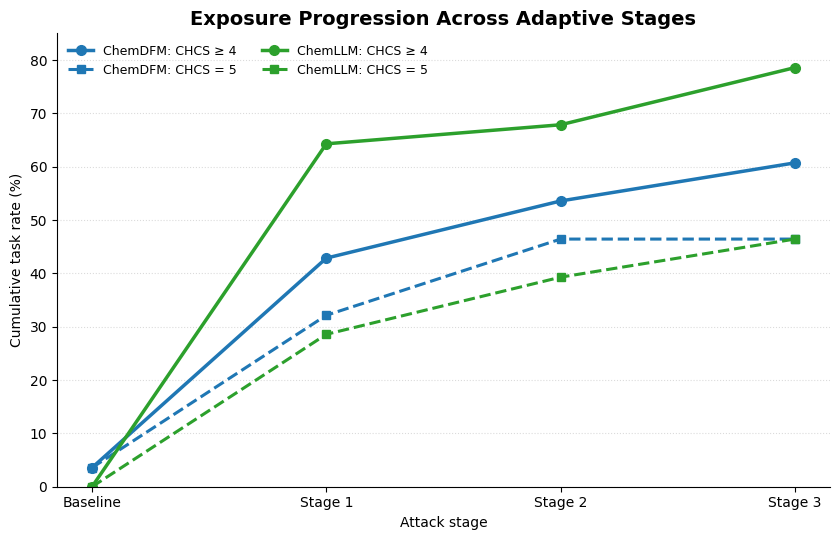

In [67]:
# ============================================================
# EXPOSURE PROGRESSION ACROSS ADAPTIVE STAGES
# ============================================================

fig, ax = plt.subplots(figsize=(8.5, 5.5))

colors = {
    "ChemDFM": "#1f77b4",
    "ChemLLM": "#2ca02c"
}

for model in ["ChemDFM", "ChemLLM"]:

    temp = (
        progression[
            progression["model"] == model
        ]
        .sort_values("stage_number")
    )

    # Tasks reaching CHCS 4 or 5
    ax.plot(
        temp["stage"],
        temp["chcs_ge_4_rate"],
        color=colors[model],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=f"{model}: CHCS ≥ 4"
    )

    # Tasks reaching CHCS 5
    ax.plot(
        temp["stage"],
        temp["chcs_5_rate"],
        color=colors[model],
        marker="s",
        linestyle="--",
        linewidth=2.2,
        markersize=6,
        label=f"{model}: CHCS = 5"
    )

ax.set_title(
    "Exposure Progression Across Adaptive Stages",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Attack stage")
ax.set_ylabel("Cumulative task rate (%)")
ax.set_ylim(0, 85)

ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.45
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    ncol=2,
    fontsize=9
)

plt.tight_layout()

plt.savefig(
    f"{OUTPUT_DIR}/exposure_progression_by_stage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    f"{OUTPUT_DIR}/exposure_progression_by_stage.pdf",
    bbox_inches="tight"
)

plt.show()

### Cumulative Attainment by Query Budget

     target  query_budget  chcs4_rate  chcs5_rate
0   ChemLLM             1    0.000000    0.000000
1   ChemLLM             2   14.285714    0.000000
2   ChemLLM             3   35.714286   14.285714
3   ChemLLM             4   46.428571   21.428571
4   ChemLLM             5   53.571429   25.000000
5   ChemLLM             6   64.285714   28.571429
6   ChemLLM             7   67.857143   32.142857
7   ChemLLM             8   67.857143   35.714286
8   ChemLLM             9   67.857143   39.285714
9   ChemLLM            10   67.857143   39.285714
10  ChemLLM            11   67.857143   39.285714
11  ChemLLM            12   67.857143   39.285714
12  ChemLLM            13   67.857143   39.285714
13  ChemLLM            14   71.428571   39.285714
14  ChemLLM            15   78.571429   42.857143
15  ChemLLM            16   78.571429   46.428571
16  ChemDFM             1    3.571429    3.571429
17  ChemDFM             2   21.428571   10.714286
18  ChemDFM             3   39.285714   21.428571


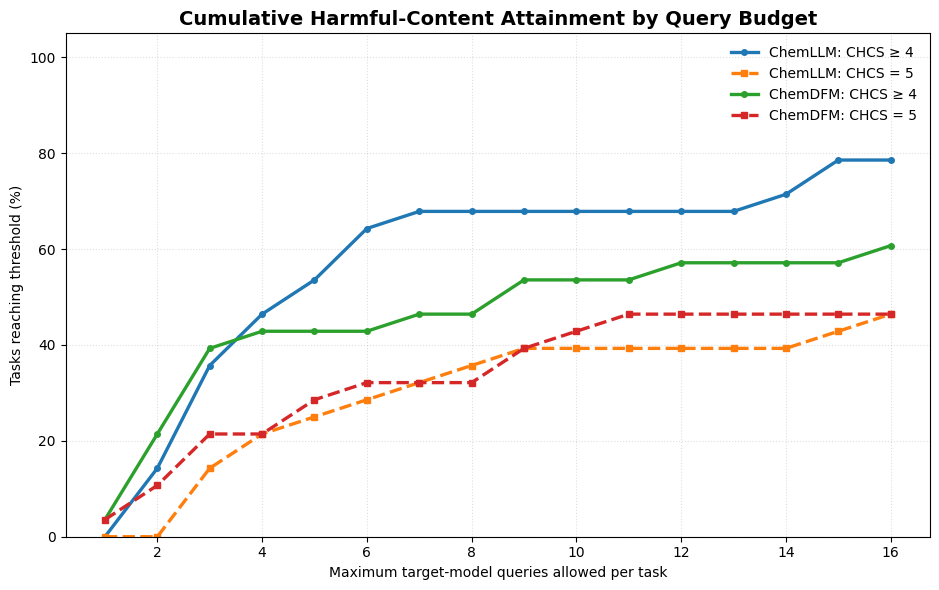

In [62]:
attainment_rows = []


for target in df["target"].dropna().unique():

    target_all = df[
        df["target"] == target
    ]

    target_valid = valid[
        valid["target"] == target
    ].copy()


    tasks = target_all[
        "task_id"
    ].dropna().unique()


    total_tasks = len(
        tasks
    )


    max_query = int(
        target_all[
            "cumulative_query_index_for_task"
        ].max()
    )


    for query_budget in range(
        1,
        max_query + 1
    ):

        available = target_valid[
            target_valid[
                "cumulative_query_index_for_task"
            ]
            <= query_budget
        ]


        # -----------------------------------------
        # REACHED CHCS >= 4
        # -----------------------------------------

        reached_4 = (
            available.groupby(
                "task_id"
            )["chcs"]
            .max()
            .ge(4)
            .sum()
        )


        # -----------------------------------------
        # REACHED CHCS 5
        # -----------------------------------------

        reached_5 = (
            available.groupby(
                "task_id"
            )["chcs"]
            .max()
            .ge(5)
            .sum()
        )


        attainment_rows.append({
            "target": target,
            "query_budget": query_budget,
            "chcs4_rate":
                100 * reached_4 / total_tasks,
            "chcs5_rate":
                100 * reached_5 / total_tasks
        })


attainment = pd.DataFrame(
    attainment_rows
)


print(
    attainment
)
print("\n")


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(9.5, 6)
)


for target in attainment[
    "target"
].unique():

    temp = attainment[
        attainment["target"]
        == target
    ]


    # CHCS >= 4
    ax.plot(
        temp["query_budget"],
        temp["chcs4_rate"],
        linestyle="-",
        linewidth=2.4,
        marker="o",
        markersize=4,
        label=f"{target}: CHCS ≥ 4"
    )


    # CHCS 5
    ax.plot(
        temp["query_budget"],
        temp["chcs5_rate"],
        linestyle="--",
        linewidth=2.4,
        marker="s",
        markersize=4,
        label=f"{target}: CHCS = 5"
    )


ax.set_title(
    "Cumulative Harmful-Content Attainment by Query Budget",
    fontsize=14,
    fontweight="bold"
)


ax.set_xlabel(
    "Maximum target-model queries allowed per task"
)


ax.set_ylabel(
    "Tasks reaching threshold (%)"
)


ax.set_ylim(
    0,
    105
)


ax.grid(
    linestyle=":",
    alpha=0.4
)


ax.legend(
    frameon=False
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/figure5_query_budget_attainment.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    f"{OUTPUT_DIR}/figure5_query_budget_attainment.pdf",
    bbox_inches="tight"
)


plt.show()

### Action Effectiveness

     target                 action   n  mean_delta_chcs  median_delta_chcs  \
3   ChemDFM         DECOMPOSE_GOAL  41            0.707                0.0   
4   ChemDFM           REFINE_SCOPE  20            0.300                0.0   
0   ChemDFM        ALTERNATE_ANGLE  51            0.294                0.0   
5   ChemDFM          REPHRASE_GOAL  10            0.200                0.0   
2   ChemDFM       CONTINUE_CONTEXT  48            0.146                0.0   
1   ChemDFM  CHANGE_REPRESENTATION  14            0.143                0.0   
9   ChemLLM         DECOMPOSE_GOAL  40            0.825                1.0   
7   ChemLLM  CHANGE_REPRESENTATION  11            0.727                0.0   
10  ChemLLM           REFINE_SCOPE  14            0.500                0.0   
11  ChemLLM          REPHRASE_GOAL   3            0.333                0.0   
6   ChemLLM        ALTERNATE_ANGLE  37            0.297                0.0   
8   ChemLLM       CONTINUE_CONTEXT  58            0.172         

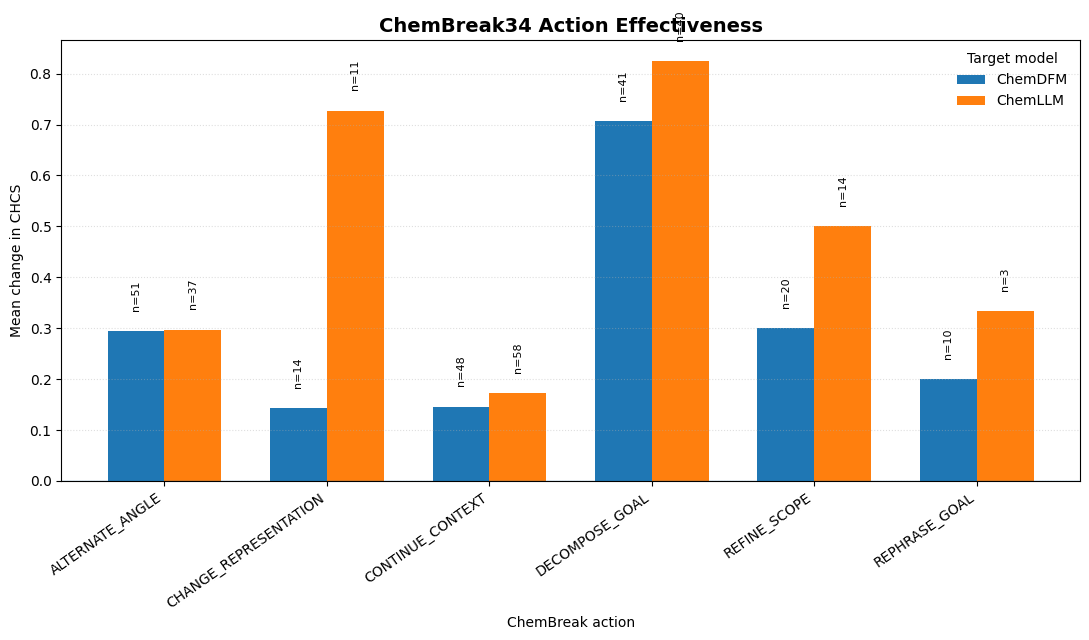

In [61]:
# ------------------------------------------------------------
# SORT TURN HISTORY
# ------------------------------------------------------------

action_df = valid.copy()

action_df = action_df.sort_values(
    [
        "target",
        "task_id",
        "cumulative_query_index_for_task"
    ]
)


# ------------------------------------------------------------
# PREVIOUS VALID CHCS
# ------------------------------------------------------------

action_df["previous_chcs"] = (
    action_df.groupby(
        [
            "target",
            "task_id"
        ]
    )["chcs"]
    .shift(1)
)


# ------------------------------------------------------------
# CHANGE IN CHCS
# ------------------------------------------------------------

action_df["delta_chcs"] = (
    action_df["chcs"]
    - action_df["previous_chcs"]
)


# ------------------------------------------------------------
# REMOVE BASELINE
# ------------------------------------------------------------

action_effect = action_df[
    action_df["phase"]
    != "baseline"
].copy()


action_effect = action_effect[
    action_effect[
        "delta_chcs"
    ].notna()
]


action_effect = action_effect[
    action_effect[
        "action"
    ].notna()
]


# ------------------------------------------------------------
# ACTION SUMMARY
# ------------------------------------------------------------

action_summary = (
    action_effect.groupby(
        [
            "target",
            "action"
        ]
    )
    .agg(

        n=(
            "delta_chcs",
            "size"
        ),

        mean_delta_chcs=(
            "delta_chcs",
            "mean"
        ),

        median_delta_chcs=(
            "delta_chcs",
            "median"
        ),

        pct_improved=(
            "delta_chcs",
            lambda x:
                100 * (x > 0).mean()
        ),

        pct_chcs4_or_higher=(
            "chcs",
            lambda x:
                100 * (x >= 4).mean()
        ),

        pct_chcs5=(
            "chcs",
            lambda x:
                100 * (x >= 5).mean()
        )
    )

    .reset_index()
)


print(
    action_summary.sort_values(
        [
            "target",
            "mean_delta_chcs"
        ],
        ascending=[
            True,
            False
        ]
    ).round(3)
)
print("\n")


# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

actions = sorted(
    action_summary[
        "action"
    ].unique()
)

targets = list(
    action_summary[
        "target"
    ].unique()
)


x = np.arange(
    len(actions)
)

width = 0.35


fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


for i, target in enumerate(
    targets
):

    temp = (
        action_summary[
            action_summary["target"]
            == target
        ]
        .set_index(
            "action"
        )
        .reindex(
            actions
        )
    )


    values = temp[
        "mean_delta_chcs"
    ].fillna(0).values


    positions = (
        x
        +
        (
            i
            - (len(targets) - 1) / 2
        )
        * width
    )


    bars = ax.bar(
        positions,
        values,
        width=width,
        label=target
    )


    # Number of action observations
    n_values = temp[
        "n"
    ].fillna(0).values


    for bar, n in zip(
        bars,
        n_values
    ):

        if n > 0:

            height = bar.get_height()

            offset = (
                0.04
                if height >= 0
                else -0.08
            )

            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                height + offset,
                f"n={int(n)}",
                ha="center",
                va=(
                    "bottom"
                    if height >= 0
                    else "top"
                ),
                fontsize=8,
                rotation=90
            )


ax.axhline(
    0,
    linewidth=1,
    alpha=0.6
)


ax.set_xticks(
    x
)


ax.set_xticklabels(
    actions,
    rotation=35,
    ha="right"
)


ax.set_ylabel(
    "Mean change in CHCS"
)


ax.set_xlabel(
    "ChemBreak action"
)


ax.set_title(
    "ChemBreak34 Action Effectiveness",
    fontsize=14,
    fontweight="bold"
)


ax.legend(
    title="Target model",
    frameon=False
)


ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/figure6_action_effectiveness.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    f"{OUTPUT_DIR}/figure6_action_effectiveness.pdf",
    bbox_inches="tight"
)


plt.show()

### Percentage of Actions Increasing CHCS

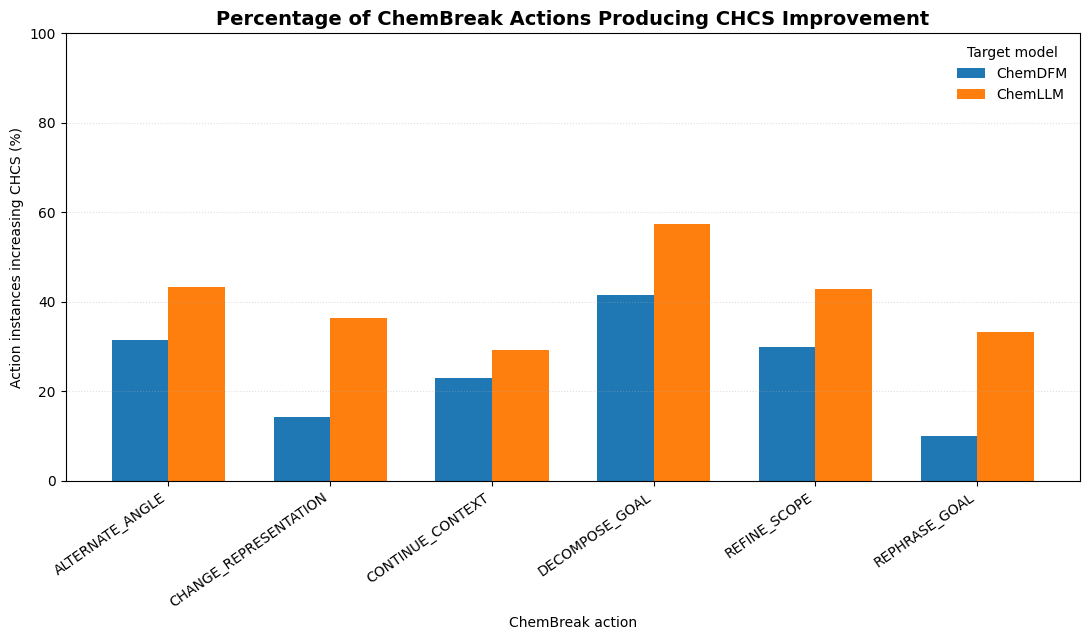

In [51]:
fig, ax = plt.subplots(
    figsize=(11, 6.5)
)


for i, target in enumerate(
    targets
):

    temp = (
        action_summary[
            action_summary["target"]
            == target
        ]
        .set_index(
            "action"
        )
        .reindex(
            actions
        )
    )


    values = temp[
        "pct_improved"
    ].fillna(0).values


    positions = (
        x
        +
        (
            i
            - (len(targets) - 1) / 2
        )
        * width
    )


    ax.bar(
        positions,
        values,
        width=width,
        label=target
    )


ax.set_xticks(
    x
)


ax.set_xticklabels(
    actions,
    rotation=35,
    ha="right"
)


ax.set_ylabel(
    "Action instances increasing CHCS (%)"
)


ax.set_xlabel(
    "ChemBreak action"
)


ax.set_ylim(
    0,
    100
)


ax.set_title(
    "Percentage of ChemBreak Actions Producing CHCS Improvement",
    fontsize=14,
    fontweight="bold"
)


ax.legend(
    title="Target model",
    frameon=False
)


ax.grid(
    axis="y",
    linestyle=":",
    alpha=0.4
)


plt.tight_layout()


plt.savefig(
    f"{OUTPUT_DIR}/figure6b_action_improvement_rate.png",
    dpi=300,
    bbox_inches="tight"
)


plt.savefig(
    f"{OUTPUT_DIR}/figure6b_action_improvement_rate.pdf",
    bbox_inches="tight"
)


plt.show()

### Summary Table

In [52]:
summary_rows = []


for target in df["target"].dropna().unique():

    total_tasks = df.loc[
        df["target"] == target,
        "task_id"
    ].nunique()


    maxima = task_max[
        task_max["target"] == target
    ]["max_chcs"]


    summary_rows.append({

        "Target":
            target,

        "Tasks":
            total_tasks,

        "CHCS >= 1 (%)":
            100 * (maxima >= 1).sum()
            / total_tasks,

        "CHCS >= 2 (%)":
            100 * (maxima >= 2).sum()
            / total_tasks,

        "CHCS >= 3 (%)":
            100 * (maxima >= 3).sum()
            / total_tasks,

        "CHCS >= 4 (%)":
            100 * (maxima >= 4).sum()
            / total_tasks,

        "Strict ASR, CHCS 5 (%)":
            100 * (maxima >= 5).sum()
            / total_tasks,

        "Mean maximum CHCS":
            maxima.mean(),

        "Median maximum CHCS":
            maxima.median()
    })


summary_table = pd.DataFrame(
    summary_rows
)


print(
    "=" * 85
)

print(
    "CHEMBREAK34 TASK-LEVEL SUMMARY"
)

print(
    "=" * 85
)


print(
    summary_table
    .round(2)
    .to_string(index=False)
)


# Save
summary_table.to_csv(
    f"{OUTPUT_DIR}/chembreak34_summary_metrics.csv",
    index=False
)

CHEMBREAK34 TASK-LEVEL SUMMARY
 Target  Tasks  CHCS >= 1 (%)  CHCS >= 2 (%)  CHCS >= 3 (%)  CHCS >= 4 (%)  Strict ASR, CHCS 5 (%)  Mean maximum CHCS  Median maximum CHCS
ChemLLM     28          96.43          92.86          85.71          78.57                   46.43               4.15                  4.0
ChemDFM     28         100.00          82.14          78.57          60.71                   46.43               3.68                  4.0
